# EDA — CineMatch | MovieLens 32M
Análisis exploratorio del dataset público MovieLens 32M.
El objetivo es verificar la calidad de los datos, detectar anomalías 
y preparar el terreno para la fase de limpieza.

### 1 - Carga de datos 

Cargamos los 4 ficheros CSV del dataset MoviLens 32M desde "data/raw".
Los resultados esperados segun la documentacion oficial son : 
- ratings: 32.000.204 filas × 4 columnas
- movies: 87.585 filas × 3 columnas
- links: 87.585 filas × 3 columnas
- tags: 2.000.072 filas × 4 columnas

In [1]:
import pandas as pd
import os

# Ruta relativa desde la carpeta del notebook hacia data/raw/
BASE_PATH = "../../../data/raw"

ratings = pd.read_csv(f"{BASE_PATH}/ratings.csv")
movies  = pd.read_csv(f"{BASE_PATH}/movies.csv")
links   = pd.read_csv(f"{BASE_PATH}/links.csv")
tags    = pd.read_csv(f"{BASE_PATH}/tags.csv")

print("ratings:", ratings.shape)
print("movies: ", movies.shape)
print("links:  ", links.shape)
print("tags:   ", tags.shape)

print(" Datos recargados correctamente")

ratings: (32000204, 4)
movies:  (87585, 3)
links:   (87585, 3)
tags:    (2000072, 4)
 Datos recargados correctamente


### 2. Calidad de los datos - nulos y tipos 

Verificamos que no hay valores nulos en los campos clave y que los tipos de datos son correctos 

In [2]:
for nombre, df in [("ratings", ratings),("movies", movies),("links", links), ("tags", tags)]:
    print(f"=== {nombre} ===")
    print(df.dtypes)
    print("Nulos:\n", df.isnull().sum())
    print()

=== ratings ===
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
Nulos:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

=== movies ===
movieId    int64
title        str
genres       str
dtype: object
Nulos:
 movieId    0
title      0
genres     0
dtype: int64

=== links ===
movieId      int64
imdbId       int64
tmdbId     float64
dtype: object
Nulos:
 movieId      0
imdbId       0
tmdbId     124
dtype: int64

=== tags ===
userId       int64
movieId      int64
tag            str
timestamp    int64
dtype: object
Nulos:
 userId        0
movieId       0
tag          17
timestamp     0
dtype: int64



### 3. Primera vista de cada fichero

In [3]:
print("=== ratings ===")
display(ratings.head(3))

print("=== movies ===")
display(movies.head(3))

print("=== links ===")
display(links.head(3))

print("=== tags ===")
display(tags.head(3))

=== ratings ===


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976


=== movies ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


=== links ===


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


=== tags ===


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469


In [4]:
# Inspeccionamos todos los casos anómalos detectados

# 1. Películas sin tmdbId — no podrán enriquecerse con TMDB API
peliculas_sin_tmdb = links[links["tmdbId"].isna()]
print(f"Películas sin tmdbId: {len(peliculas_sin_tmdb)}")
sin_tmdb_info = peliculas_sin_tmdb.merge(movies, on="movieId")
display(sin_tmdb_info.head(10))

# 2. Tags con etiqueta vacía — se eliminarán en la limpieza
tags_nulos = tags[tags["tag"].isna()]
print(f"\nTags con etiqueta vacía: {len(tags_nulos)}")
display(tags_nulos)

# 3. tmdbId viene como float64 por los nulos — lo convertimos a Int64 (nullable integer)
links["tmdbId"] = links["tmdbId"].astype("Int64")
print(f"\ntmdbId convertido a: {links['tmdbId'].dtype}")

Películas sin tmdbId: 124


,movieId,imdbId,tmdbId,title,genres
0,721,114103,NaN,Halfmoon (Paul Bowles - Halbmond) (1995),Drama
1,730,125877,NaN,Low Life (1994),Drama
2,770,38426,NaN,Costa Brava (1946),Drama
3,791,113610,NaN,"Last Klezmer: Leopold Kozlowski, His Life and ...",Documentary
4,1107,102336,NaN,Loser (1991),Comedy
5,1142,116403,NaN,Get Over It (1996),Drama
6,1316,115548,NaN,Anna (1996),Drama
7,1421,113212,NaN,Grateful Dead (1995),Documentary
8,1434,123281,NaN,"Stranger, The (1994)",Action
9,1630,123953,NaN,"Lay of the Land, The (1997)",Comedy|Drama



Tags con etiqueta vacía: 17


,userId,movieId,tag,timestamp
185377,27046,33826,NaN,1221450908
1394089,89369,281500,NaN,1670942104
1914668,153443,123,NaN,1199450867
1914669,153443,346,NaN,1199451946
1914673,153443,1184,NaN,1199452261
1914680,153443,1785,NaN,1199452006
1914681,153443,2194,NaN,1199450677
1914683,153443,2691,NaN,1199451002
1914691,153443,4103,NaN,1199451920
1914693,153443,4473,NaN,1199451040



tmdbId convertido a: Int64


### 4. Observaciones de calidad 

- `ratings`: sin nulos, tipos correctos.
- `movies`: sin nulos. Los géneros vienen separados por `|` → se normalizarán en la fase de limpieza.
- `links`: 124 nulos en `tmdbId`. Estas películas no tendrán poster ni sinopsis via TMDB API. Se gestionarán mostrando solo datos locales como plan B.
- `tags`: 17 nulos en la columna `tag`. Son registros donde el usuario dejó la etiqueta vacía → se eliminarán en la fase de limpieza.
- `tmdbId` aparece como `float64` en vez de `int` porque pandas convierte automáticamente columnas con nulos.

### 5. Distribucion de ratings 
- Analizamos como se distribuyen las valoraciones para entender el comportamiento general de los usuarios 

Valores unicos de ratings: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Distribución:
 rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64


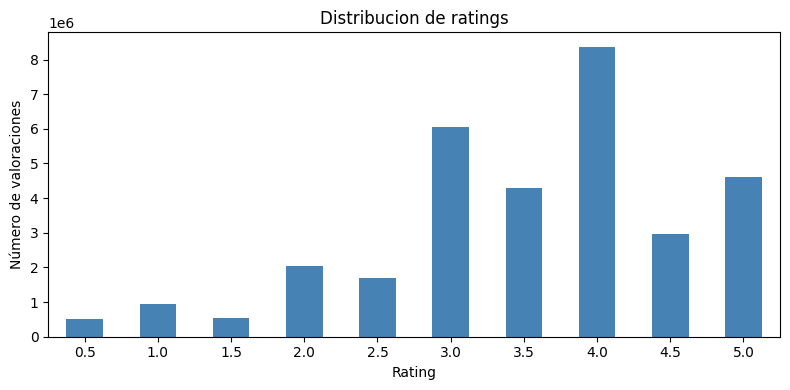

In [5]:
import matplotlib.pyplot as plt 

# Distribucion de ratings
# Los ratings van de 0.5 a 5.0 en incrementos de 0.5
print ("Valores unicos de ratings:", sorted(ratings["rating"].unique()))
print("Distribución:\n", ratings["rating"].value_counts().sort_index())

# histograma
plt.figure(figsize=(8,4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Distribucion de ratings")
plt.xlabel("Rating")
plt.ylabel("Número de valoraciones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Observaciones — Distribución de ratings
- Los 10 valores esperados están presentes (0.5 a 5.0 en incrementos de 0.5).
- **Sesgo positivo claro** : el rating más frecuente es 4.0 (8.3M valoraciones), 
  seguido de 3.0 (6M) y 5.0 (4.6M).
- Los ratings bajos (0.5 y 1.0) son minoritarios — los usuarios tienden a valorar 
  cosas que ya les gustan, no todo lo que ven.
- Este sesgo es conocido en sistemas de recomendación y puede afectar al modelo → 
  se tendrá en cuenta en la evaluación con métricas como Precision@K y Recall@K.

### 6. Actividad de usuarios
Analizamos cuántas valoraciones tiene cada usuario para detectar 
usuarios muy activos (outliers) y verificar el mínimo de 20 ratings 
que garantiza el dataset según su documentación oficial.

Total usuarios: 200948
Mínimo ratings por usuario : 20
Máximo ratings por usuario : 33332
Media ratings por usuario  : 159.2
Mediana ratings por usuario: 73.0

Usuarios con más de 1000 ratings: 3614


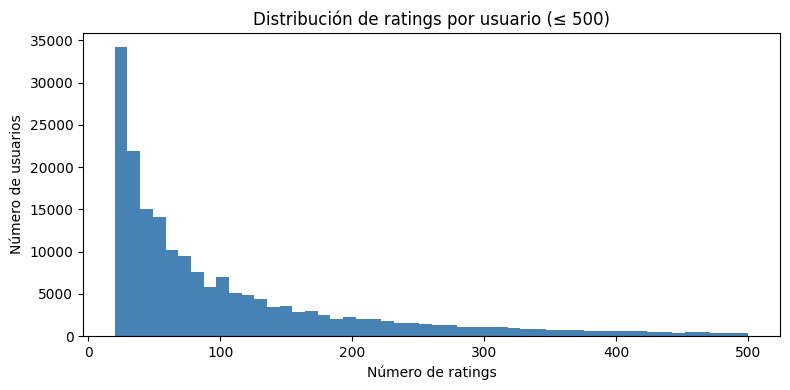

In [6]:
# Calculamos cuántos ratings tiene cada usuario
ratings_por_usuario = ratings.groupby("userId")["rating"].count()

print(f"Total usuarios: {ratings_por_usuario.shape[0]}")
print(f"Mínimo ratings por usuario : {ratings_por_usuario.min()}")
print(f"Máximo ratings por usuario : {ratings_por_usuario.max()}")
print(f"Media ratings por usuario  : {ratings_por_usuario.mean():.1f}")
print(f"Mediana ratings por usuario: {ratings_por_usuario.median():.1f}")

# Usuarios con más de 1000 ratings — posibles outliers
usuarios_muy_activos = ratings_por_usuario[ratings_por_usuario > 1000]
print(f"\nUsuarios con más de 1000 ratings: {len(usuarios_muy_activos)}")

# Histograma — limitamos a 500 para que sea legible
plt.figure(figsize=(8, 4))
ratings_por_usuario[ratings_por_usuario <= 500].plot(
    kind="hist", bins=50, color="steelblue"
)
plt.title("Distribución de ratings por usuario (≤ 500)")
plt.xlabel("Número de ratings")
plt.ylabel("Número de usuarios")
plt.tight_layout()
plt.show()

#### Observaciones — Actividad de usuarios

- Mínimo de 20 ratings por usuario confirmado — coincide con la documentación oficial.
- Total de 200.948 usuarios — coincide con la documentación oficial.
- **Alta asimetría** : la media es 159 pero la mediana es 73 — significa que 
  unos pocos usuarios muy activos están tirando la media hacia arriba.
- **3.614 usuarios con más de 1.000 ratings** — son outliers que pueden 
  sesgar el modelo si no se controlan. Se aplicará un umbral máximo en la limpieza.
- El usuario más activo tiene 33.332 ratings — prácticamente ha valorado 
  el 38% del catálogo completo (87.585 películas).

### 7. Popularidad de películas
Analizamos cuántas valoraciones tiene cada película para detectar 
películas infrarrepresentadas (cold start) y películas 
excesivamente dominantes (popularity bias).

Total películas con al menos 1 rating : 84432
Total películas en catálogo            : 87585
Películas sin ningún rating            : 3153

Mínimo ratings por película : 1
Máximo ratings por película : 102929
Media ratings por película  : 379.0
Mediana ratings por película: 5.0

Películas con menos de 5 ratings: 40548

Top 10 películas más valoradas:


,title,num_ratings
0,"Shawshank Redemption, The (1994)",102929
1,Forrest Gump (1994),100296
2,Pulp Fiction (1994),98409
3,"Matrix, The (1999)",93808
4,"Silence of the Lambs, The (1991)",90330
5,Star Wars: Episode IV - A New Hope (1977),85010
6,Fight Club (1999),77332
7,Jurassic Park (1993),75233
8,Schindler's List (1993),73849
9,"Lord of the Rings: The Fellowship of the Ring,...",73122


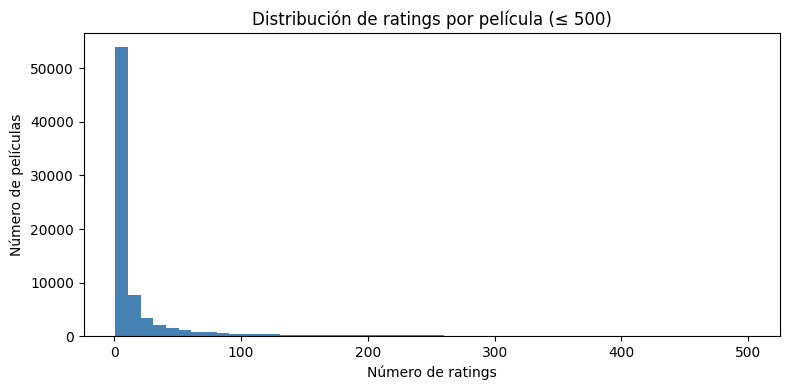

In [7]:
# Calculamos cuántos ratings tiene cada película
ratings_por_pelicula = ratings.groupby("movieId")["rating"].count()

print(f"Total películas con al menos 1 rating : {ratings_por_pelicula.shape[0]}")
print(f"Total películas en catálogo            : {movies.shape[0]}")
print(f"Películas sin ningún rating            : {movies.shape[0] - ratings_por_pelicula.shape[0]}")
print(f"\nMínimo ratings por película : {ratings_por_pelicula.min()}")
print(f"Máximo ratings por película : {ratings_por_pelicula.max()}")
print(f"Media ratings por película  : {ratings_por_pelicula.mean():.1f}")
print(f"Mediana ratings por película: {ratings_por_pelicula.median():.1f}")

# Películas con menos de 5 ratings — candidatas a cold start
peliculas_frias = ratings_por_pelicula[ratings_por_pelicula < 5]
print(f"\nPelículas con menos de 5 ratings: {len(peliculas_frias)}")

# Top 10 películas más valoradas
top10 = ratings_por_pelicula.sort_values(ascending=False).head(10)
top10_info = top10.reset_index().merge(movies, on="movieId")
top10_info.columns = ["movieId", "num_ratings", "title", "genres"]
print("\nTop 10 películas más valoradas:")
display(top10_info[["title", "num_ratings"]])

# Histograma — limitamos a 500 para que sea legible
plt.figure(figsize=(8, 4))
ratings_por_pelicula[ratings_por_pelicula <= 500].plot(
    kind="hist", bins=50, color="steelblue"
)
plt.title("Distribución de ratings por película (≤ 500)")
plt.xlabel("Número de ratings")
plt.ylabel("Número de películas")
plt.tight_layout()
plt.show()

### Observaciones — Popularidad de películas

-  **3.153 películas sin ningún rating** — existen en el catálogo pero nunca 
  han sido valoradas. El modelo no podrá recomendarlas.
-  **40.548 películas con menos de 5 ratings** — casi la mitad del catálogo 
  (46%) está infrarrepresentada. Son candidatas directas al problema de cold start.
-  **Alta asimetría extrema** : la media es 379 pero la mediana es 5 — 
  unas pocas películas acumulan la gran mayoría de valoraciones.
-  **Popularity bias muy marcado** : The Shawshank Redemption tiene 102.929 
  ratings mientras que la mitad del catálogo tiene 5 o menos. El modelo 
  tenderá a recomendar siempre las mismas películas populares.
-  El Top 10 son títulos reconocidos mundialmente — tiene sentido que sean 
  los más valorados.

**Estrategia de mitigación definida en Fase 1 :**
- Aplicar umbral mínimo de 5 ratings por película en la limpieza.
- Penalizar títulos sobre-representados en la generación del Top-K.
- Usar géneros como fallback para películas con pocos ratings.

## 8. Limpieza de datos

Aplicamos las siguientes transformaciones basadas en las observaciones del EDA:

1. Eliminar tags con etiqueta vacía
2. Aplicar umbral mínimo de 5 ratings por película
3. Aplicar umbral máximo de 10.000 ratings por usuario (outliers)
4. Normalizar géneros separados por `|` en lista estructurada
5. Convertir tmdbId a Int64

In [8]:
# ── 1. Eliminar tags vacíos ──────────────────────────────────────────────────
# 17 registros donde el usuario dejó la etiqueta vacía
tags_clean = tags.dropna(subset=["tag"])
print(f"Tags antes : {len(tags)}")
print(f"Tags después: {len(tags_clean)}")

# ── 2. Umbral mínimo de 5 ratings por película ───────────────────────────────
# Eliminamos películas infrarrepresentadas — cold start severo
peliculas_validas = ratings_por_pelicula[ratings_por_pelicula >= 5].index
ratings_clean = ratings[ratings["movieId"].isin(peliculas_validas)]
print(f"\nRatings antes : {len(ratings)}")
print(f"Ratings después (umbral película): {len(ratings_clean)}")

# ── 3. Umbral máximo de 10.000 ratings por usuario ───────────────────────────
# Eliminamos usuarios extremadamente activos que pueden sesgar el modelo
usuarios_validos = ratings_por_usuario[ratings_por_usuario <= 10000].index
ratings_clean = ratings_clean[ratings_clean["userId"].isin(usuarios_validos)]
print(f"Ratings después (umbral usuario) : {len(ratings_clean)}")

# ── 4. Normalizar géneros ────────────────────────────────────────────────────
# Convertimos "Action|Comedy|Drama" en ["Action", "Comedy", "Drama"]
movies_clean = movies.copy()
movies_clean["genres"] = movies_clean["genres"].apply(
    lambda x: x.split("|") if x != "(no genres listed)" else []
)
print(f"\nEjemplo géneros normalizados:")
display(movies_clean.head(3))

# ── 5. Convertir tmdbId a Int64 ──────────────────────────────────────────────
links_clean = links.copy()
links_clean["tmdbId"] = links_clean["tmdbId"].astype("Int64")
print(f"\ntmdbId dtype: {links_clean['tmdbId'].dtype}")



Tags antes : 2000072
Tags después: 2000055

Ratings antes : 32000204
Ratings después (umbral película): 31921467
Ratings después (umbral usuario) : 31895825

Ejemplo géneros normalizados:


,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"



tmdbId dtype: Int64


#### Observaciones — Limpieza

-  Tags vacíos eliminados : 2.000.072 → 2.000.055 (17 registros eliminados)
-  Umbral mínimo 5 ratings por película : 32.000.204 → 31.921.467 
  (78.737 ratings eliminados de películas infrarrepresentadas)
-  Umbral máximo 10.000 ratings por usuario : 31.921.467 → 31.895.825 
  (25.642 ratings eliminados de usuarios outliers)
-  Géneros normalizados correctamente de string a lista estructurada
- tmdbId convertido de float64 a Int64

**Datos finales tras limpieza : 31.895.825 ratings — pérdida del 0.3% del total, 
lo cual es aceptable y esperado.**

### 9. Submuestreo estratificado

Para el desarrollo y prototipado del modelo trabajamos con un subconjunto 
representativo de 100.000 ratings. El submuestreo es estratificado por usuario 
para mantener la proporción de interacciones y no perder diversidad.

El dataset completo (31.895.825 ratings) solo se usará en la evaluación final.

Tamaño del subconjunto        : 100000
Usuarios en el subconjunto    : 58888
Películas en el subconjunto   : 10913


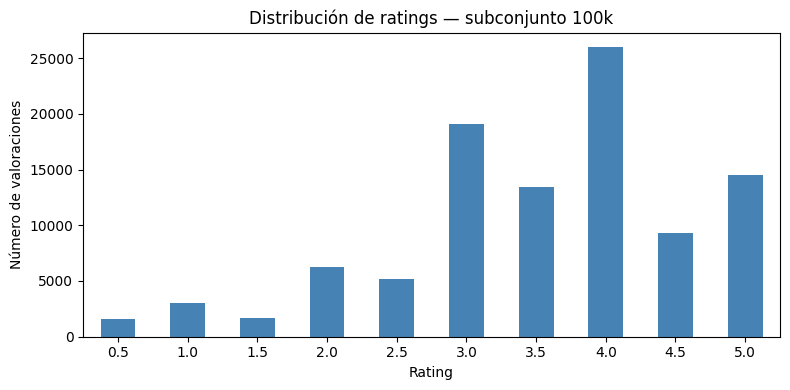

In [9]:
from sklearn.model_selection import train_test_split

# ── Submuestreo aleatorio con semilla fija ───────────────────────────────────
# Usamos random_state=42 para garantizar reproducibilidad
# Cualquier miembro del equipo obtendrá exactamente el mismo subconjunto
ratings_sample = ratings_clean.sample(n=100_000, random_state=42)

print(f"Tamaño del subconjunto        : {len(ratings_sample)}")
print(f"Usuarios en el subconjunto    : {ratings_sample['userId'].nunique()}")
print(f"Películas en el subconjunto   : {ratings_sample['movieId'].nunique()}")

# Verificamos que la distribución de ratings es similar al dataset completo
plt.figure(figsize=(8, 4))
ratings_sample["rating"].value_counts().sort_index().plot(
    kind="bar", color="steelblue"
)
plt.title("Distribución de ratings — subconjunto 100k")
plt.xlabel("Rating")
plt.ylabel("Número de valoraciones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observaciones — Submuestreo

-  100.000 ratings seleccionados con semilla fija `random_state=42` — 
  garantiza reproducibilidad para todo el equipo.
-  58.888 usuarios representados — 29% del total, diversidad suficiente.
-  10.913 películas representadas — 13% del catálogo, cubre los títulos 
  más relevantes.
- La distribución de ratings es visualmente similar al dataset completo —
  el sesgo positivo (ratings altos más frecuentes) se mantiene, 
  lo cual es esperado y correcto.

**Este subconjunto se usará  para entrenar y ajustar el modelo. 
El dataset completo solo se usará en la evaluación final.**

## 10. Exportación de datos procesados

Guardamos todos los datos limpios en `data/processed/` listos para ser 
consumidos por el modelo de Machine Learning y el backend.

Archivos exportados:
- `ratings_clean.parquet` — dataset completo limpio (31.8M ratings)
- `ratings_sample.parquet` — subconjunto 100k para desarrollo del modelo
- `movies_clean.parquet` — catálogo de películas con géneros normalizados
- `links_clean.parquet` — enlaces TMDB/IMDB con tipos corregidos
- `tags_clean.parquet` — etiquetas sin nulos

In [10]:
import os

# ── Creamos la carpeta si no existe ──────────────────────────────────────────
os.makedirs("../../../data/processed", exist_ok=True)

# ── Exportamos todo en CSV ───────────────────────────────────────────────────
# Usamos CSV por compatibilidad total con el resto del equipo
# sin dependencias adicionales de versiones de pyarrow
ratings_clean.to_csv("../../../data/processed/ratings_clean.csv", index=False)
ratings_sample.to_csv("../../../data/processed/ratings_sample.csv", index=False)
movies_clean.to_csv("../../../data/processed/movies_clean.csv", index=False)
links_clean.to_csv("../../../data/processed/links_clean.csv", index=False)
tags_clean.to_csv("../../../data/processed/tags_clean.csv", index=False)

# ── Verificamos que los archivos se han creado correctamente ─────────────────
for archivo in sorted(os.listdir("../../../data/processed")):
    ruta = f"../../../data/processed/{archivo}"
    tamanio = os.path.getsize(ruta) / (1024 * 1024)
    print(f"{archivo:40s} → {tamanio:.1f} MB")

print("\n✅ Exportación completada")

links_clean.csv                          → 1.7 MB
movies_clean.csv                         → 4.4 MB
ratings_clean.csv                        → 803.1 MB
ratings_sample.csv                       → 2.5 MB
tags_clean.csv                           → 67.1 MB

✅ Exportación completada


### Observaciones — Exportación

-  `ratings_clean.csv` → 803.1 MB — dataset completo limpio para evaluación final
-  `ratings_sample.csv` → 2.5 MB — subconjunto 100k para desarrollo del modelo
-  `movies_clean.csv` → 4.4 MB — catálogo con géneros normalizados
-  `links_clean.csv` → 1.7 MB — enlaces TMDB/IMDB con tipos corregidos
-  `tags_clean.csv` → 67.1 MB — etiquetas sin nulos

Todos los archivos están en `data/processed/` listos para ser consumidos para el entrenamiento del modelo.